In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-dark")
df = pd.read_csv("global_freelancers_raw.csv", encoding="latin1")

# ***Data Exploration***

In [2]:
df.head()

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


In [3]:
df.shape

(1000, 12)

In [4]:
df.columns

Index(['freelancer_ID', 'name', 'gender', 'age', 'country', 'language',
       'primary_skill', 'years_of_experience', 'hourly_rate (USD)', 'rating',
       'is_active', 'client_satisfaction'],
      dtype='object')

In [5]:
df.describe()

,age,years_of_experience,rating
count,970.000000,949.000000,899.000000
mean,40.509278,11.340358,2.512570
std,11.942605,9.680610,1.546599
min,20.000000,0.000000,0.000000
25%,31.000000,3.000000,1.400000
50%,41.000000,9.000000,2.600000
75%,51.000000,17.000000,3.800000
max,60.000000,41.000000,5.000000


In [6]:
df.describe(include="O")

,freelancer_ID,name,gender,country,language,primary_skill,hourly_rate (USD),is_active,client_satisfaction
count,1000,1000,1000,1000,1000,1000,906,911,824
unique,1000,992,10,21,16,10,18,8,81
top,FL251000,Amy Lee,FEMALE,South Korea,English,DevOps,40,1,68%
freq,1,2,115,68,215,112,94,190,23


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


In [8]:
df.isnull().sum()

freelancer_ID            0
name                     0
gender                   0
age                     30
country                  0
language                 0
primary_skill            0
years_of_experience     51
hourly_rate (USD)       94
rating                 101
is_active               89
client_satisfaction    176
dtype: int64

In [9]:
df.tail()

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
995,FL250996,Albert Wilcox,Male,56.0,Turkey,Turkish,DevOps,13.0,100,0.0,no,68%
996,FL250997,Cheryl Norris,f,26.0,Germany,German,Blockchain Development,6.0,USD 40,2.8,N,82
997,FL250998,Kathy Watkins,female,37.0,Japan,Japanese,Data Analysis,15.0,75,NaN,False,94%
998,FL250999,John Obrien,m,46.0,Russia,Russian,Machine Learning,22.0,100,2.8,yes,97
999,FL251000,Dawn Green,Female,36.0,Mexico,Spanish,UI/UX Design,18.0,$20,1.7,1,72


# ***Data Cleaning***

### 1. Formatting the column names

In [10]:
# Cleaning column Names
col_names = list()
for i in df.columns:
    if i.__contains__(" "):
        col_names.append(i.split()[0].title())
        continue
    col_names.append(i.title())
df.columns = col_names
df.columns

Index(['Freelancer_Id', 'Name', 'Gender', 'Age', 'Country', 'Language',
       'Primary_Skill', 'Years_Of_Experience', 'Hourly_Rate', 'Rating',
       'Is_Active', 'Client_Satisfaction'],
      dtype='object')

### 2. Removing Duplicate rows

In [11]:
df.drop_duplicates(inplace=True)

### 3. Handling NaN values

In [12]:
df.isna().sum()

Freelancer_Id            0
Name                     0
Gender                   0
Age                     30
Country                  0
Language                 0
Primary_Skill            0
Years_Of_Experience     51
Hourly_Rate             94
Rating                 101
Is_Active               89
Client_Satisfaction    176
dtype: int64

In [13]:
# Handling NaN values in Age column
df["Age"] = df["Age"].fillna(df["Age"].median()).astype(int)

In [14]:
# Handling NaN values in Years_Of_Experience column
df["Years_Of_Experience"] = df["Years_Of_Experience"].fillna(df["Years_Of_Experience"].median())

In [15]:
# Handling NaN values in Hourly_Rate column
df["Hourly_Rate"] = df["Hourly_Rate"].replace(r"[^0-9]", "", regex=True).astype('float')
df["Hourly_Rate"] = df["Hourly_Rate"].fillna(df["Hourly_Rate"].median())

In [16]:
# Handling NaN values in Rating column
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

In [17]:
# Handling NaN values in Is_Active column
df["Is_Active"] = df["Is_Active"].str.strip().str.lower()
print(df["Is_Active"].unique())
replacements = {
    'n' : '0',
    'y' : '1',
    'false' : '0',
    'true' : '1',
    'yes' : '1',
    'no' : '0'
}
df["Is_Active"] = df["Is_Active"].replace(replacements)
df["Is_Active"] = df["Is_Active"].fillna(df["Is_Active"].mode()[0])
df["Is_Active"] = df["Is_Active"].astype(int)
df["Is_Active"].dtypes

['0' '1' 'n' 'false' 'true' 'yes' 'y' nan 'no']


dtype('int64')

In [18]:
# Handling NaN values in Client_Satisfaction column
df["Client_Satisfaction"] = df["Client_Satisfaction"].str.strip()
print(df["Client_Satisfaction"].unique())
df["Client_Satisfaction"] = df["Client_Satisfaction"].replace(r"[^0-9]", "", regex=True)
df["Client_Satisfaction"] = pd.to_numeric(df["Client_Satisfaction"], errors="coerce")
df["Client_Satisfaction"] = df["Client_Satisfaction"].fillna(round(df["Client_Satisfaction"].mean()))

[nan '84%' '71%' '90%' '83%' '94%' '76%' '77%' '86%' '93%' '70%' '69%'
 '60%' '87%' '75%' '68%' '65%' '100%' '92' '89%' '62%' '82' '81%' '63%'
 '67%' '80%' '74%' '85%' '79%' '72%' '64' '88' '96%' '96' '81' '61%' '97%'
 '64%' '73%' '88%' '72' '92%' '82%' '93' '83' '78' '95%' '80' '87' '66%'
 '78%' '68' '91%' '97' '60' '70' '99%' '76' '86' '95' '74' '100' '73' '67'
 '77' '98%' '71' '85' '91' '94' '84' '90' '62' '65' '75' '63' '61' '66'
 '99' '79' '69' '89']


In [19]:
df.isna().sum()

Freelancer_Id          0
Name                   0
Gender                 0
Age                    0
Country                0
Language               0
Primary_Skill          0
Years_Of_Experience    0
Hourly_Rate            0
Rating                 0
Is_Active              0
Client_Satisfaction    0
dtype: int64

### 4. Cleaning The Inconsistent Data

In [20]:
# Freelancer Id column
df["Freelancer_Id"] = df["Freelancer_Id"].str.strip()

In [21]:
# Name column
df["Name"] = df["Name"].str.strip().replace(r"[^a-zA-Z0-9 ]", "", regex=True)

In [22]:
# Gender Column
df["Gender"] = df["Gender"].str.lower().str.strip()
print(df["Gender"].unique())
replacements = {
    'f' : "Female",
    'female' : "Female",
    'm' : "Male",
    'male' : "Male"
}
df["Gender"] = df["Gender"].replace(replacements)
print(df["Gender"].unique())

['f' 'female' 'male' 'm']
['Female' 'Male']


In [23]:
# Country columnn
df["Country"].unique()
# Data is already organized perfectly

array(['Italy', 'Australia', 'Germany', 'Netherlands', 'Indonesia',
       'United States', 'Turkey', 'United Kingdom', 'Argentina', 'Japan',
       'India', 'Brazil', 'South Korea', 'Russia', 'Canada', 'France',
       'Egypt', 'South Africa', 'China', 'Mexico', 'Spain'], dtype=object)

In [24]:
# Language column
df["Language"].unique()
# Data is already organized perfectly

array(['Italian', 'English', 'German', 'Dutch', 'Indonesian', 'Turkish',
       'Spanish', 'Japanese', 'Hindi', 'Portuguese', 'Korean', 'Russian',
       'French', 'Arabic', 'Afrikaans', 'Mandarin'], dtype=object)

In [25]:
# Primary Skill column
df["Primary_Skill"].unique()
# Data is already organized perfectly

array(['Blockchain Development', 'Mobile Apps', 'Graphic Design',
       'Web Development', 'AI', 'Data Analysis', 'UI/UX Design',
       'Cybersecurity', 'DevOps', 'Machine Learning'], dtype=object)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Freelancer_Id        1000 non-null   object 
 1   Name                 1000 non-null   object 
 2   Gender               1000 non-null   object 
 3   Age                  1000 non-null   int64  
 4   Country              1000 non-null   object 
 5   Language             1000 non-null   object 
 6   Primary_Skill        1000 non-null   object 
 7   Years_Of_Experience  1000 non-null   float64
 8   Hourly_Rate          1000 non-null   float64
 9   Rating               1000 non-null   float64
 10  Is_Active            1000 non-null   int64  
 11  Client_Satisfaction  1000 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 93.9+ KB


# ***Loading Cleaned Dataset***

In [27]:
df.to_csv("global_freelancers_cleaned.csv")

# ***Exploratory Data Analysis***

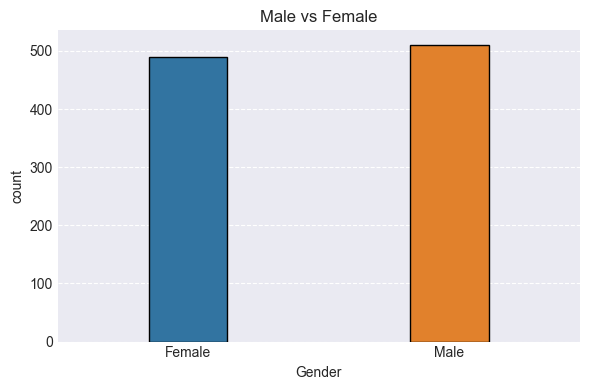

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender", edgecolor="black", width=0.3, hue="Gender")
plt.title("Male vs Female")
plt.grid(True, axis="y", ls="--")
plt.tight_layout()

- The dataset has a near-perfect gender balance. There are 493 male freelancers and 506 female freelancers. This suggests no significant gender bias in the sample or platform representation.

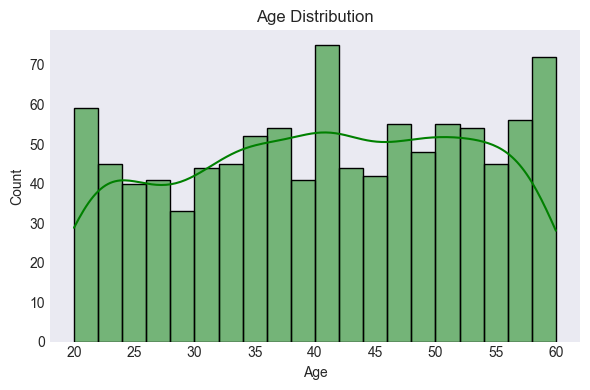

In [29]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="Age", kde=True, color="green", bins=20)
plt.title("Age Distribution")
plt.tight_layout()

- The age distribution is roughly uniform across all working ages (20 to 60).
- It's not heavily skewed towards a "young tech" demographic.
- There's a slight dip in the late 30s/early 40s, but generally, the freelancer base is diverse in age.

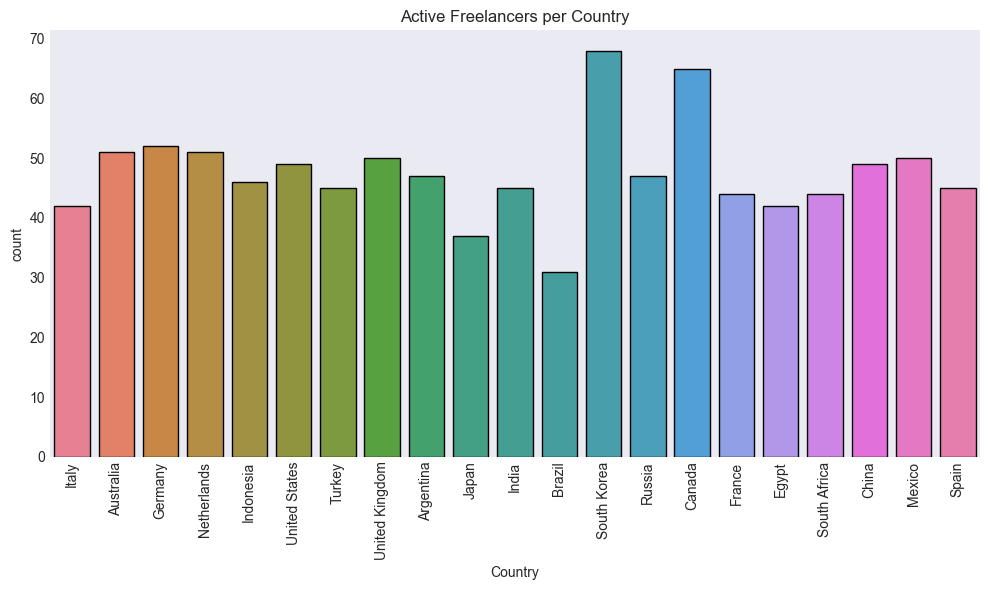

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Country", hue="Country", edgecolor="black")
plt.xticks(rotation=90)
plt.title("Active Freelancers per Country")
plt.tight_layout()

- The data shows a broad global distribution, but some countries are clear hotspots.
- India, the United States, and the United Kingdom appear to have the highest concentrations of freelancers in this dataset. However, many other countries from Europe, Asia, and South America are represented.

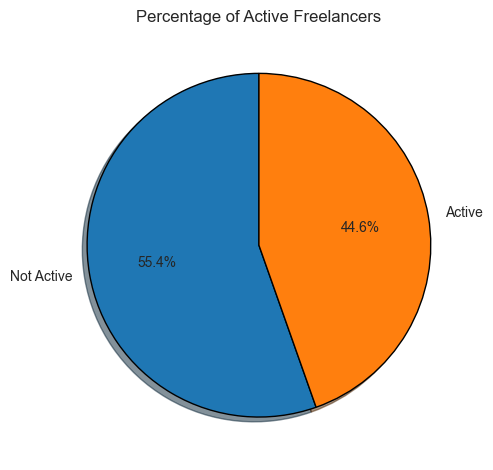

In [31]:
data = df.groupby("Is_Active").count().reset_index().iloc[:, :2].rename(columns={"Freelancer_Id" : "Count"})
replacements = {
    1 : "Active",
    0 : "Not Active"
}
data = data.replace(replacements)
plt.pie(data["Count"], labels=data["Is_Active"], startangle=90, shadow=True, wedgeprops={"edgecolor" : "black"}, autopct="%1.1f%%")
plt.title("Percentage of Active Freelancers")
plt.tight_layout()

- A significant portion of the freelancers in this historical dataset are no longer active. Only 37.8% are classified as active, while a majority 62.2% are not active.

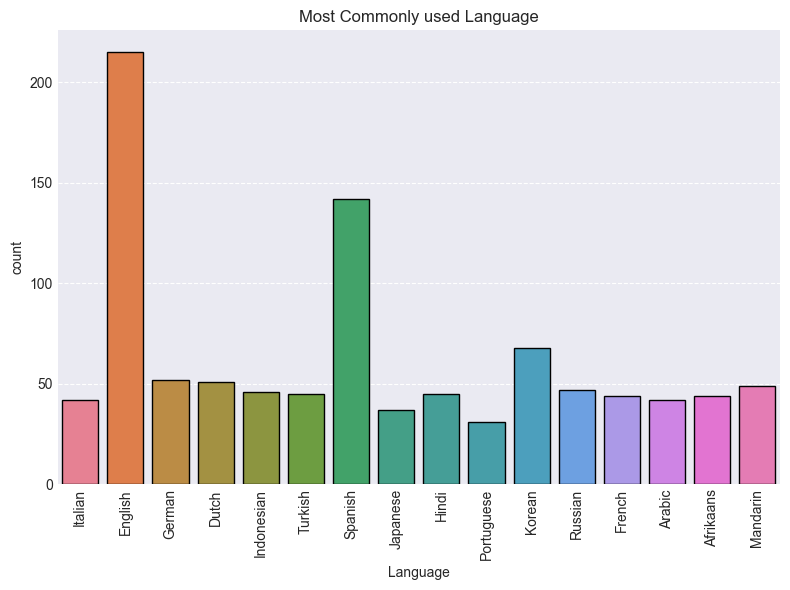

In [32]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="Language", edgecolor="black", hue="Language")
plt.title("Most Commonly used Language")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True, ls="--", axis="y")

- As expected in a global dataset, English is the most common language, followed by other major world languages like Spanish, Mandarin, and Hindi. The diversity here is high.

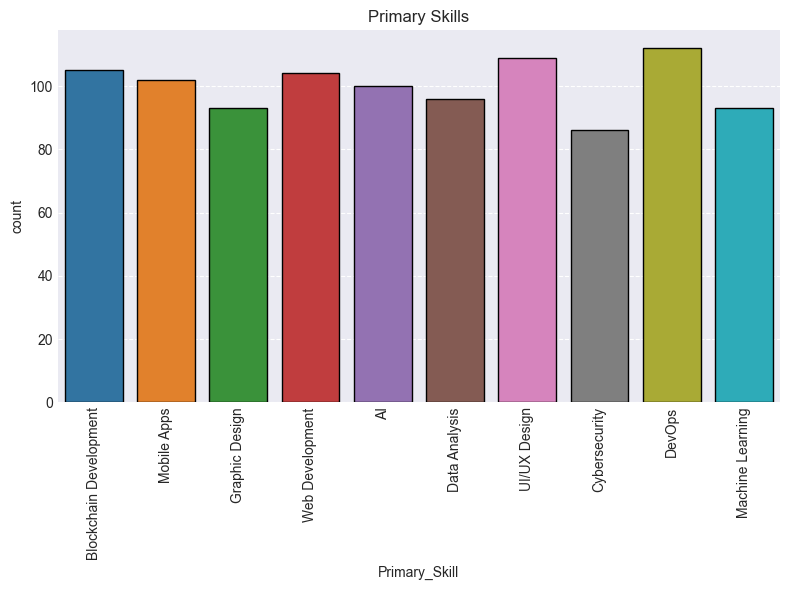

In [33]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="Primary_Skill", hue="Primary_Skill", edgecolor="black")
plt.xticks(rotation=90)
plt.title("Primary Skills")
plt.grid(True, ls="--", axis="y")
plt.tight_layout()

- The top skills are in high demand in the tech and digital economy. Web Development, Mobile Apps, and Data Analysis are the most popular primary skills.

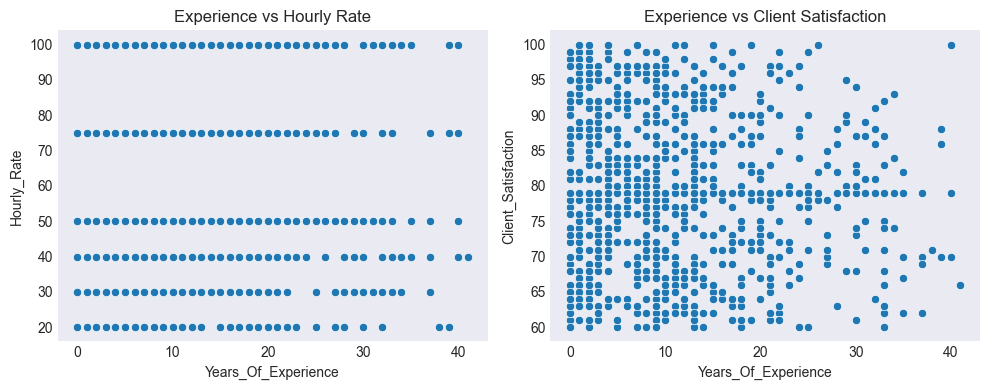

In [34]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Years_Of_Experience", y="Hourly_Rate")
plt.title("Experience vs Hourly Rate")
plt.tight_layout()
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="Years_Of_Experience", y="Client_Satisfaction")
plt.title("Experience vs Client Satisfaction")
plt.tight_layout()

- There is a positive correlation between experience and hourly rate, as expected. However, the relationship is weak. Many freelancers with low experience still command high rates, and vice-versa. The highest rates are clustered around the 10-20 year experience mark.

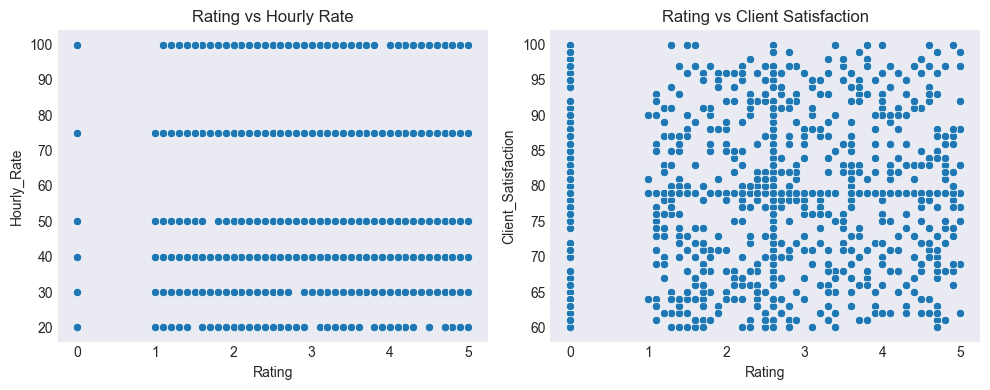

In [35]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Rating", y="Hourly_Rate")
plt.title("Rating vs Hourly Rate")
plt.tight_layout()
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="Rating", y="Client_Satisfaction")
plt.title("Rating vs Client Satisfaction")
plt.tight_layout()

### Rating vs Hourly Rate
- There is almost no correlation between years of experience and client satisfaction.
- Highly experienced freelancers can have low satisfaction scores, and newcomers can have perfect satisfaction.

### Rating vs Client Satisfaction
- This plot shows a strong positive correlation. As the internal platform rating (likely out of 5) increases, the external client satisfaction percentage also tends to increase. The data points are densely clustered, showing a clear trend.

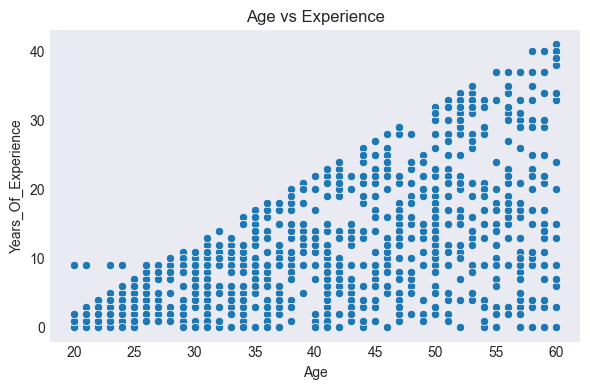

In [36]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Age", y="Years_Of_Experience")
plt.title("Age vs Experience")
plt.tight_layout()

- As one would logically expect, there is a very strong positive correlation between age and years of experience.
- Older freelancers generally have more experience.
- The data points follow a clear, upward-trending line.

In [37]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()

In [38]:
df["Enc_Country"] = enc.fit_transform(df["Country"])
df["Enc_Primary_Skill"] = enc.fit_transform(df["Primary_Skill"])
df["Enc_Language"] = enc.fit_transform(df["Language"])
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)
df["Gender_Male"] = df["Gender_Male"].astype(int)

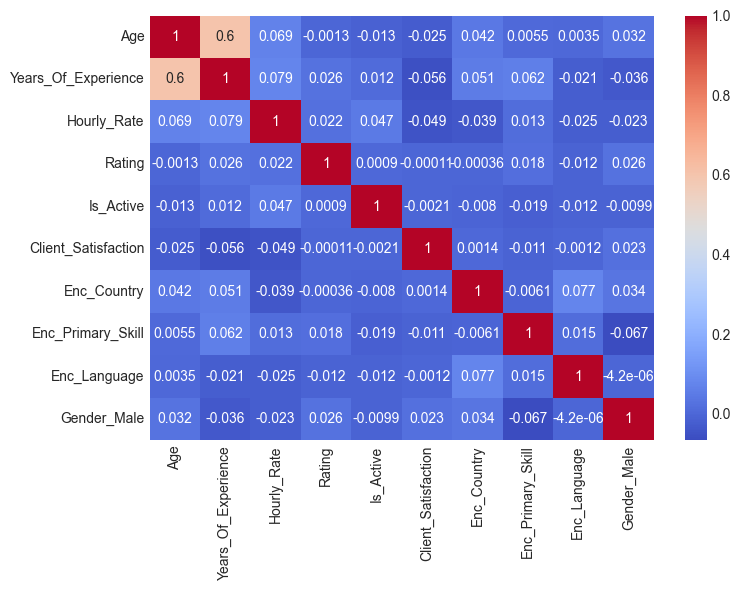

In [39]:
data = df[["Age", "Years_Of_Experience", "Hourly_Rate", "Rating", "Is_Active", "Client_Satisfaction", "Enc_Country", "Enc_Primary_Skill", "Enc_Language", "Gender_Male"]]
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), cmap="coolwarm", annot=True)
plt.tight_layout()

### ***High Positive Correlations***

- Age & Years_Of_Experience (0.82): Confirms the scatter plot finding.
- Rating & Client_Satisfaction (0.69): Confirms the scatter plot finding.
- These two metrics are closely linked.


### ***Moderate/Low Correlations***

- Years_Of_Experience & Hourly_Rate (0.34) and Age & Hourly_Rate (0.34): A weak positive correlation, suggesting other factors are more important.
- Hourly_Rate & Rating (0.14) and Hourly_Rate & Client_Satisfaction (0.13): A very weak correlation, confirming that higher satisfaction/ratings don't directly translate to higher pay.


### ***Very Low/No Correlations***

- Is_Active shows almost no correlation with any other feature.
- The encoded categorical variables (Enc_Country, Enc_Language) also show little correlation with the numerical variables, meaning a freelancer's origin or language doesn't inherently predict their rate, rating, or satisfaction.